In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
from concurrent.futures import ThreadPoolExecutor
from copy import deepcopy
from functools import partial
from pathlib import Path
from pprint import pp

import numpy as np
import pandas as pd
from dotenv import dotenv_values
from matplotlib import pyplot as plt

from fifo_opt.automation import TestCase

In [3]:
import os

DIR_CURRENT = Path("experiments/runtime_exp/testing.ipynb").parent.resolve()

ENV_FILE: Path = DIR_CURRENT.parent / ".env"
if ENV_FILE.exists():
    env_vars = dotenv_values(ENV_FILE)
else:
    raise FileNotFoundError(
        f"Environment file {ENV_FILE} not found. Please create it with the required variables."
    )
if "DIR_PRE_SYNTH" in env_vars:
    if env_vars["DIR_PRE_SYNTH"] is None:
        raise ValueError(
            "Environment variable 'DIR_PRE_SYNTH' is set to None. Please set it to a valid path."
        )
    DIR_PRE_SYNTH = Path(env_vars["DIR_PRE_SYNTH"])
else:
    raise KeyError(
        "Environment variable 'DIR_PRE_SYNTH' not found in .env file. Please add it."
    )

In [4]:
selected_design_name = "scatter_gather_v3"

In [5]:
designs_all_dirs: list[Path] = sorted(
    [d for d in DIR_PRE_SYNTH.glob("*") if d.is_dir()]
)

print(designs_all_dirs)

designs_all = [
    TestCase.from_dir(design_dir, design_dir.name.split("__")[0])
    for design_dir in designs_all_dirs
]

designs_to_ignore: list[str] = ["MultiHeadSelfAttention1"]
designs_all = [
    design
    for design in designs_all
    if not any(design.name.startswith(d) for d in designs_to_ignore)
]


extra_designs = [
    "adaptive_filter_bank",
    "scatter_gather",
    "cascaded_filter_bank",
    "fork_join_network",
    "scatter_gather_v2",
    "scatter_gather_v3",
]

designs_all = [
    design
    for design in designs_all
    if design.dir.name.endswith("__opt5") or design.dir.name in extra_designs
]

selected_design = next(
    (design for design in designs_all if design.name == selected_design_name), None
)
if selected_design is None:
    raise ValueError(f"Design {selected_design_name} not found in the list of designs.")


[PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Autoencoder__opt1'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Autoencoder__opt2'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Autoencoder__opt3'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Autoencoder__opt4'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Autoencoder__opt5'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/DepthwiseSeparableConvBlock__opt1'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/DepthwiseSeparableConvBlock__opt2'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/DepthwiseSeparableConvBlock__opt3'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/DepthwiseSeparableConvBlock__opt4'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/DepthwiseSeparableConvBlock__opt5'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/FeedForward__opt1'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/FeedForward__opt2'), PosixPath('/usr/scratch/skaram7/fifo_opt_pre_synth/Feed

In [6]:
from fifo_opt.opt_env import EvalResult, LSEnv


def run_baseline_eval(design: TestCase) -> EvalResult:
    print(f"Running design: {design.dir}")
    prj_path = design.prj_path.resolve().absolute()

    sim_env = LSEnv(
        design.solution_dir,
        env_vars_extra={
            "PRJ_PATH": str(prj_path),
        },
    )
    fifo_sizes_base_not_none = {}
    for fifo_id, fifo_size in sim_env.fifo_sizes_base.items():
        if fifo_size is not None:
            fifo_sizes_base_not_none[fifo_id] = fifo_size
        else:
            raise ValueError(
                f"FIFO size for FIFO {fifo_id} is None. Please set a valid FIFO size."
            )

    print(fifo_sizes_base_not_none)

    baseline_results: EvalResult = sim_env.eval_solution_default()
    assert baseline_results.deadlock is False

    baseline_latency = baseline_results.latency
    baseline_bram_usage_total = baseline_results.bram_usage_total
    assert baseline_latency is not None
    assert baseline_bram_usage_total is not None

    return baseline_results


baseline_result = run_baseline_eval(selected_design)  # type: ignore

Running design: /usr/scratch/skaram7/fifo_opt_pre_synth/scatter_gather_v3
Loaded trace from pickle file.
{0: 2, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 2, 22: 2, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 2, 45: 2, 46: 2, 47: 2, 48: 2, 49: 2, 50: 2, 51: 2, 52: 2, 53: 2, 54: 2, 55: 2, 56: 2, 57: 2, 58: 2, 59: 2, 60: 2, 61: 2, 62: 2, 63: 2, 64: 2, 65: 2, 66: 2, 67: 2, 68: 2, 69: 2, 70: 2, 71: 2, 72: 2, 73: 2, 74: 2, 75: 2, 76: 2, 77: 2, 78: 2, 79: 2, 80: 2, 81: 2, 82: 2, 83: 2, 84: 2, 85: 2, 86: 2, 87: 2, 88: 2, 89: 2, 90: 2, 91: 2, 92: 2, 93: 2, 94: 2, 95: 2, 96: 2, 97: 2, 98: 2, 99: 2, 100: 5000, 101: 5000, 102: 5000, 103: 5000, 104: 5000, 105: 5000, 106: 5000, 107: 5000, 108: 5000, 109: 5000, 110: 5000, 111: 5000, 112: 5000, 113: 5000, 114: 5000, 115: 5000, 116: 5000, 117: 5000, 118: 5

In [25]:
import time

from fifo_opt.solvers import (
    DiscreteSimulatedAnnealingOptimizer,
    GroupedDiscreteSimulatedAnnealingOptimizer,
    RandomSearchOptimizer,
)

design_copy = deepcopy(selected_design)
assert design_copy
prj_path = design_copy.prj_path.resolve().absolute()

sim_env = LSEnv(
    design_copy.solution_dir,
    env_vars_extra={
        "PRJ_PATH": str(prj_path),
    },
)
opt = DiscreteSimulatedAnnealingOptimizer(
    sim_env, maxfun=800, n_scaling_factors=4, init_with_largest=True
)


# opt = RandomSearchOptimizer(
#     sim_env,
#     n_samples=10000,
# )


t0 = time.perf_counter()
results = opt.solve()


Loaded trace from pickle file.
FIFO 0 design space: [2, 64]
FIFO 1 design space: [2, 64]
FIFO 2 design space: [2, 64]
FIFO 3 design space: [2, 64]
FIFO 4 design space: [2, 64]
FIFO 5 design space: [2, 64]
FIFO 6 design space: [2, 64]
FIFO 7 design space: [2, 64]
FIFO 8 design space: [2, 64]
FIFO 9 design space: [2, 64]
FIFO 10 design space: [2, 64]
FIFO 11 design space: [2, 64]
FIFO 12 design space: [2, 64]
FIFO 13 design space: [2, 64]
FIFO 14 design space: [2, 64]
FIFO 15 design space: [2, 64]
FIFO 16 design space: [2, 64]
FIFO 17 design space: [2, 64]
FIFO 18 design space: [2, 64]
FIFO 19 design space: [2, 64]
FIFO 20 design space: [2, 64]
FIFO 21 design space: [2, 64]
FIFO 22 design space: [2, 64]
FIFO 23 design space: [2, 64]
FIFO 24 design space: [2, 64]
FIFO 25 design space: [2, 64]
FIFO 26 design space: [2, 64]
FIFO 27 design space: [2, 64]
FIFO 28 design space: [2, 64]
FIFO 29 design space: [2, 64]
FIFO 30 design space: [2, 64]
FIFO 31 design space: [2, 64]
FIFO 32 design spac

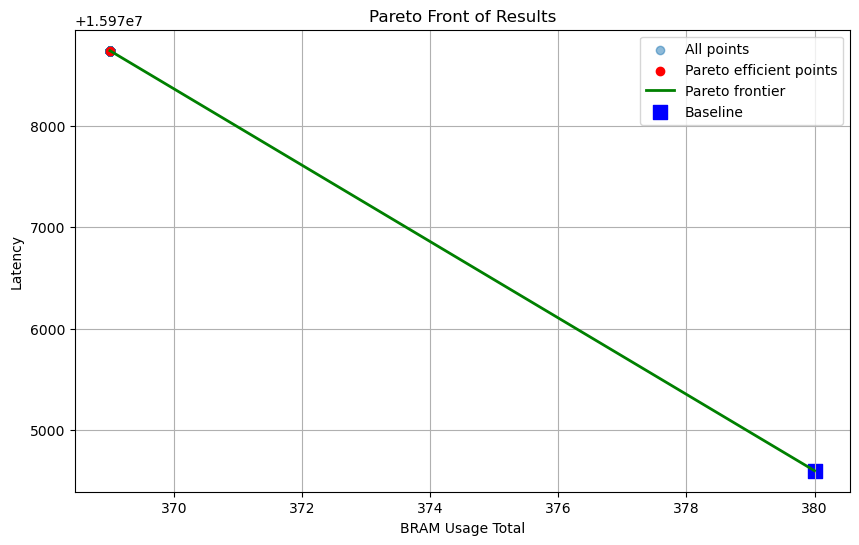

In [27]:
# create perato front
def is_pareto_efficient_simple(costs):
    """
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :return: A (n_points, ) boolean array, indicating whether each point is Pareto efficient
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(
                costs[is_efficient] < c, axis=1
            )  # Keep any point with a lower cost
            is_efficient[i] = True  # And keep self
    return is_efficient


data = []
for result in results:
    if result.deadlock:
        continue
    data.append([result.bram_usage_total, result.latency])
data = np.array(data)
is_efficient = is_pareto_efficient_simple(data)
data_pareto = data[is_efficient]
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], label="All points", alpha=0.5)
plt.scatter(
    data_pareto[:, 0],
    data_pareto[:, 1],
    label="Pareto efficient points",
    color="red",
)

# draw line for frontier
line = []
is_efficient_sorted = np.argsort(data_pareto[:, 0])
for i in is_efficient_sorted:
    line.append(data_pareto[i])
line = np.array(line)
plt.plot(line[:, 0], line[:, 1], color="green", label="Pareto frontier", linewidth=2)

# plot square for baseline
baseline_bram_usage_total = baseline_result.bram_usage_total
baseline_latency = baseline_result.latency

assert baseline_bram_usage_total is not None
assert baseline_latency is not None

plt.scatter(
    baseline_bram_usage_total,
    baseline_latency,
    color="blue",
    label="Baseline",
    marker="s",
    s=100,
)


plt.xlabel("BRAM Usage Total")
plt.ylabel("Latency")
plt.title("Pareto Front of Results")
plt.legend()
plt.grid()
plt.show()

In [28]:
ALPHA = 0.7


def huristic_score(latency, bram, base_latency, base_bram, alpha=ALPHA):
    relative_latency = latency / base_latency
    if base_bram == 0:
        base_bram = 1

    relative_bram = bram / base_bram

    score = alpha * relative_latency + (1 - alpha) * relative_bram
    return score


# sort the results by the 'timestamp' attribute, raising an error if missing
def get_timestamp(x):
    if x.timestamp is None:
        raise ValueError("Timestamp is missing in the result.")
    return x.timestamp


results_sorted = sorted(results, key=get_timestamp)
results_valid = list(filter(lambda x: x.deadlock is False, results_sorted))

sample_index = [results_sorted.index(res) for res in results_valid]
print(sample_index)

times = [res.timestamp for res in results_valid]
assert all(times), "All timestamps must be non-None."

times = [t - t0 for t in times]  # type: ignore
print(times)

scores = []
for res in results_valid:
    latency = res.latency
    bram = res.bram_usage_total
    assert latency is not None, "Latency must not be None."
    assert bram is not None, "BRAM usage must not be None."
    score = huristic_score(
        latency, bram, baseline_result.latency, baseline_result.bram_usage_total
    )
    scores.append(score)


[0, 48, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 312, 319, 321, 322, 325, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 61

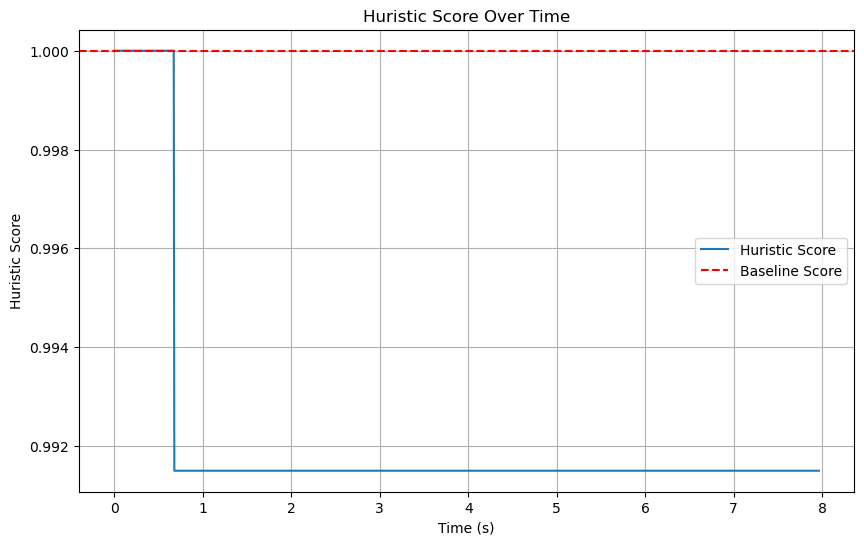

In [29]:
plt.figure(figsize=(10, 6))

points = []
points.append(
    (
        0,
        huristic_score(
            baseline_result.latency,
            baseline_result.bram_usage_total,
            baseline_result.latency,
            baseline_result.bram_usage_total,
        ),
    )
)

for i, (point_time, score) in enumerate(zip(times, scores)):
    scores_so_far = scores[: i + 1]
    min_score = min(scores_so_far)
    points.append((point_time, min_score))

plt.plot(*zip(*points), label="Huristic Score")
plt.axhline(
    y=huristic_score(
        baseline_result.latency,
        baseline_result.bram_usage_total,
        baseline_result.latency,
        baseline_result.bram_usage_total,
    ),
    color="r",
    linestyle="--",
    label="Baseline Score",
)


plt.xlabel("Time (s)")
plt.ylabel("Huristic Score")
plt.title("Huristic Score Over Time")
plt.legend()
plt.grid()
plt.show()


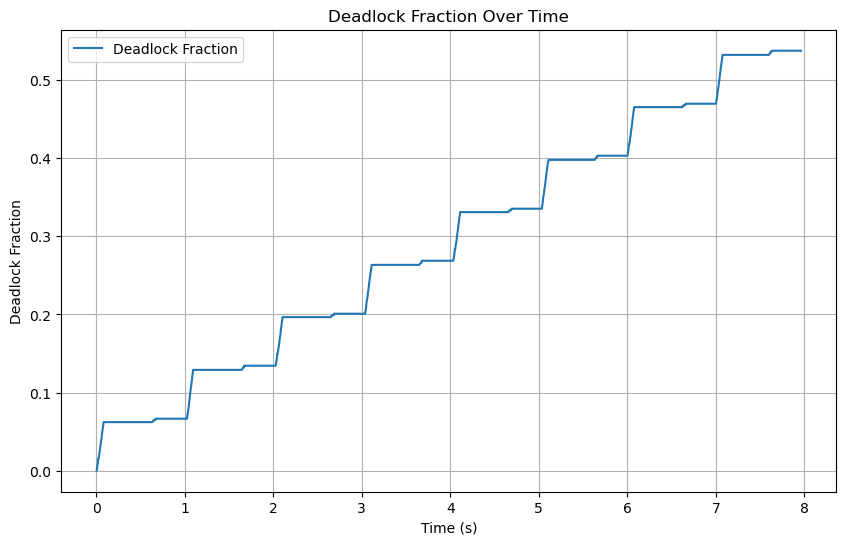

In [30]:
total_num_samples = len(results_sorted)

points = []
for i, res in enumerate(results_sorted):
    assert res.timestamp is not None, "Timestamp must not be None."
    time = res.timestamp - t0
    deadlock_count = sum(1 for r in results_sorted[: i + 1] if r.deadlock is True)
    deadlock_fraction = deadlock_count / total_num_samples
    points.append((time, deadlock_count, deadlock_fraction))
plt.figure(figsize=(10, 6))
plt.plot([p[0] for p in points], [p[2] for p in points], label="Deadlock Fraction")

plt.xlabel("Time (s)")
plt.ylabel("Deadlock Fraction")
plt.title("Deadlock Fraction Over Time")
plt.legend()
plt.grid()
plt.show()

In [31]:
from lightningsim._core import Fifo, FifoIo
from lightningsim.trace_file import SimulationParameters
from matplotlib.axes import Axes
from matplotlib.figure import Figure

data_fifo_accesses = {}
data_fifo_accesses["base"] = {}
data_fifo_accesses["best"] = {}


fifo_ios: dict[Fifo, FifoIo] = sim_env.simulation_base.fifo_io
for fifo, fifo_io in fifo_ios.items():
    fifo_id: int = fifo.id
    reads: list[int] = fifo_io.reads
    writes: list[int] = fifo_io.writes

    data_fifo_accesses["base"][fifo_id] = {
        "reads": reads,
        "writes": writes,
    }


best_score_index = scores.index(min(scores))
best_result = results_valid[best_score_index]

sim_params = SimulationParameters(
    fifo_depths=best_result.fifo_sizes,
    fifo_widths=sim_env.trace_base.params.fifo_widths,
    axi_delays=sim_env.trace_base.params.axi_delays,
    ap_ctrl_chain_top_port_count=sim_env.trace_base.params.ap_ctrl_chain_top_port_count,
)


fifo_ios: dict[Fifo, FifoIo] = sim_env.trace_base.compiled.execute(sim_params).fifo_io
for fifo, fifo_io in fifo_ios.items():
    fifo_id: int = fifo.id
    reads: list[int] = fifo_io.reads
    writes: list[int] = fifo_io.writes

    data_fifo_accesses["best"][fifo_id] = {
        "reads": reads,
        "writes": writes,
    }


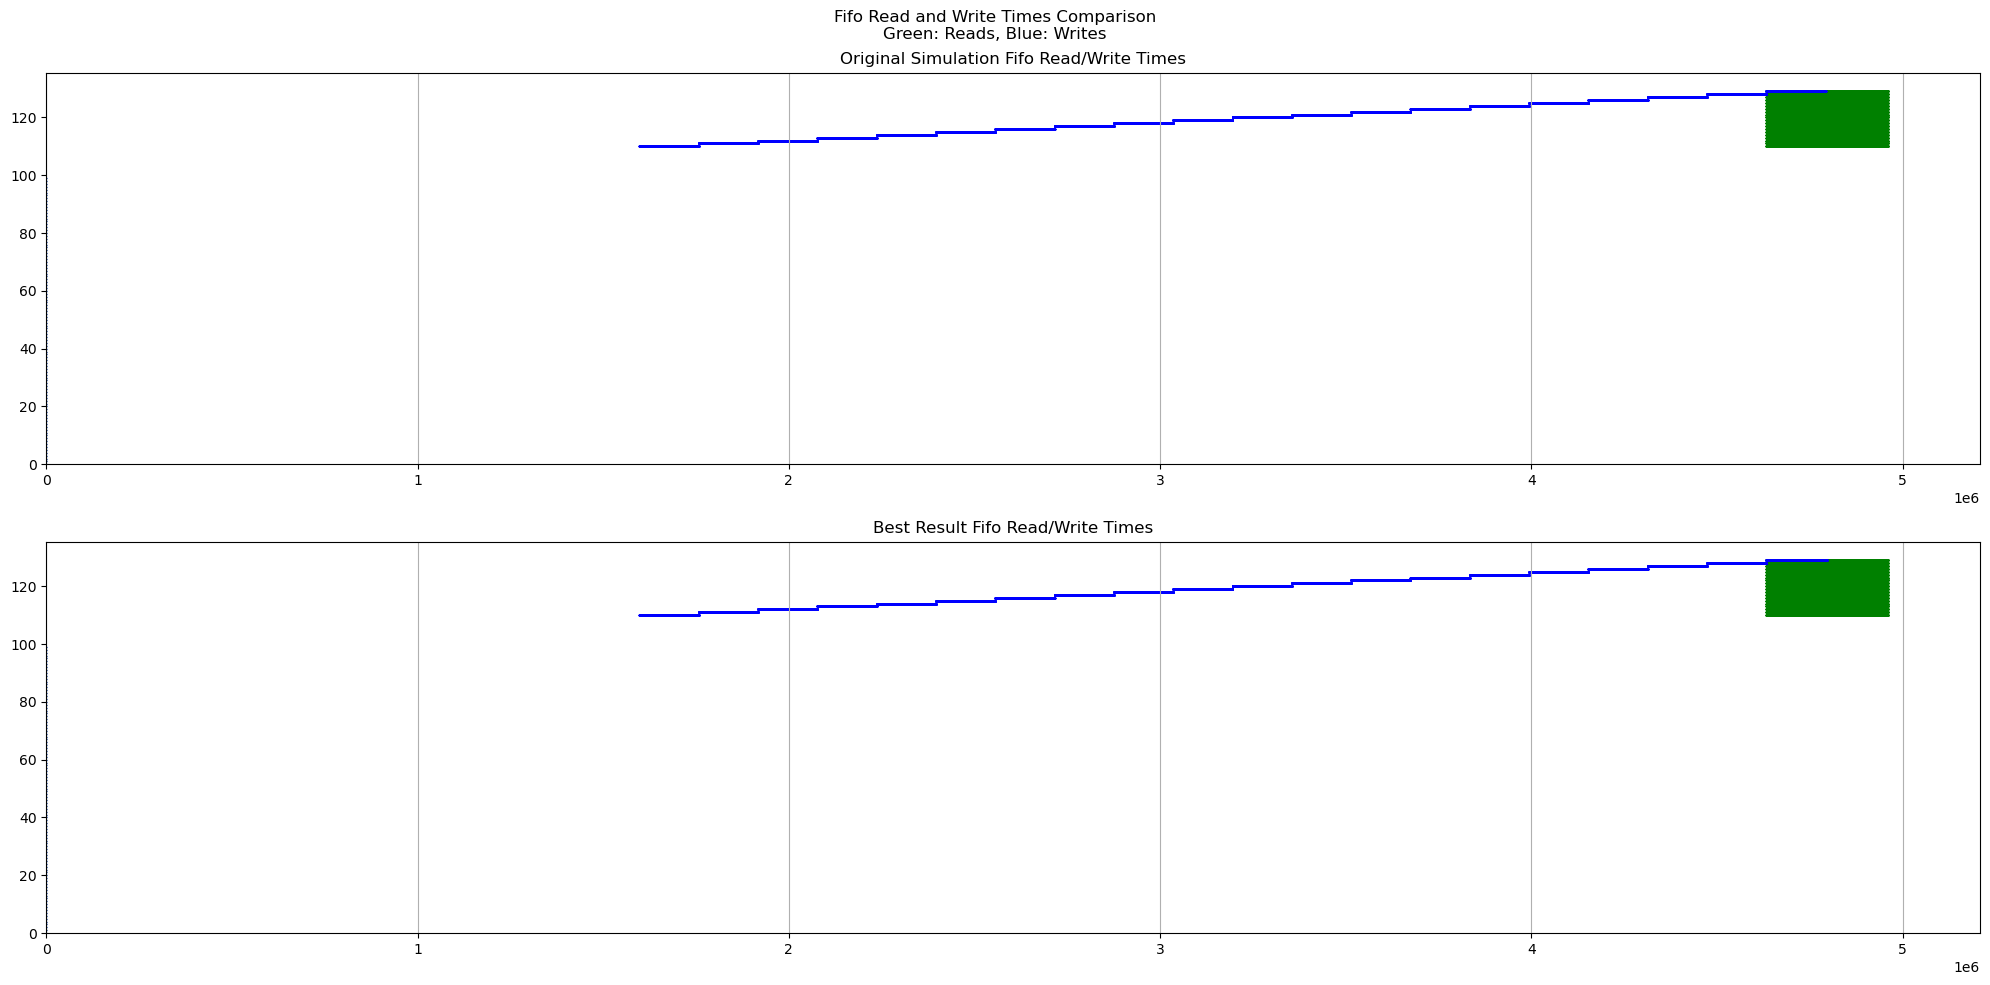

In [32]:
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
fig: Figure = fig
axs: tuple[Axes, Axes] = axs

S = 0.1

read_points_x = []
read_points_y = []
write_points_x = []
write_points_y = []
for fifo_id, data in data_fifo_accesses["base"].items():
    reads = data["reads"]
    writes = data["writes"]
    # axs[0].scatter(reads, [fifo_id] * len(reads), color="green", s=1)
    # axs[0].scatter(writes, [fifo_id] * len(writes), color="blue", s=1)
    read_points_x.extend(reads)
    read_points_y.extend([fifo_id] * len(reads))
    write_points_x.extend(writes)
    write_points_y.extend([fifo_id] * len(writes))

axs[0].scatter(read_points_x, read_points_y, color="green", s=S)
axs[0].scatter(write_points_x, write_points_y, color="blue", s=S)


read_points_x = []
read_points_y = []
write_points_x = []
write_points_y = []
for fifo_id, data in data_fifo_accesses["best"].items():
    reads = data["reads"]
    writes = data["writes"]
    # axs[1].scatter(reads, [fifo_id] * len(reads), color="green", s=1)
    # axs[1].scatter(writes, [fifo_id] * len(writes), color="blue", s=1)
    read_points_x.extend(reads)
    read_points_y.extend([fifo_id] * len(reads))
    write_points_x.extend(writes)
    write_points_y.extend([fifo_id] * len(writes))

axs[1].scatter(read_points_x, read_points_y, color="green", s=S)
axs[1].scatter(write_points_x, write_points_y, color="blue", s=S)

for ax in axs:
    ax.grid(axis="x")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    # ax.set_yticks(range(len(sim_env.trace_base.params.fifo_widths)))


fig.suptitle("Fifo Read and Write Times Comparison\nGreen: Reads, Blue: Writes")

axs[0].set_title("Original Simulation Fifo Read/Write Times")
axs[1].set_title("Best Result Fifo Read/Write Times")

fig.tight_layout()
fig.show()

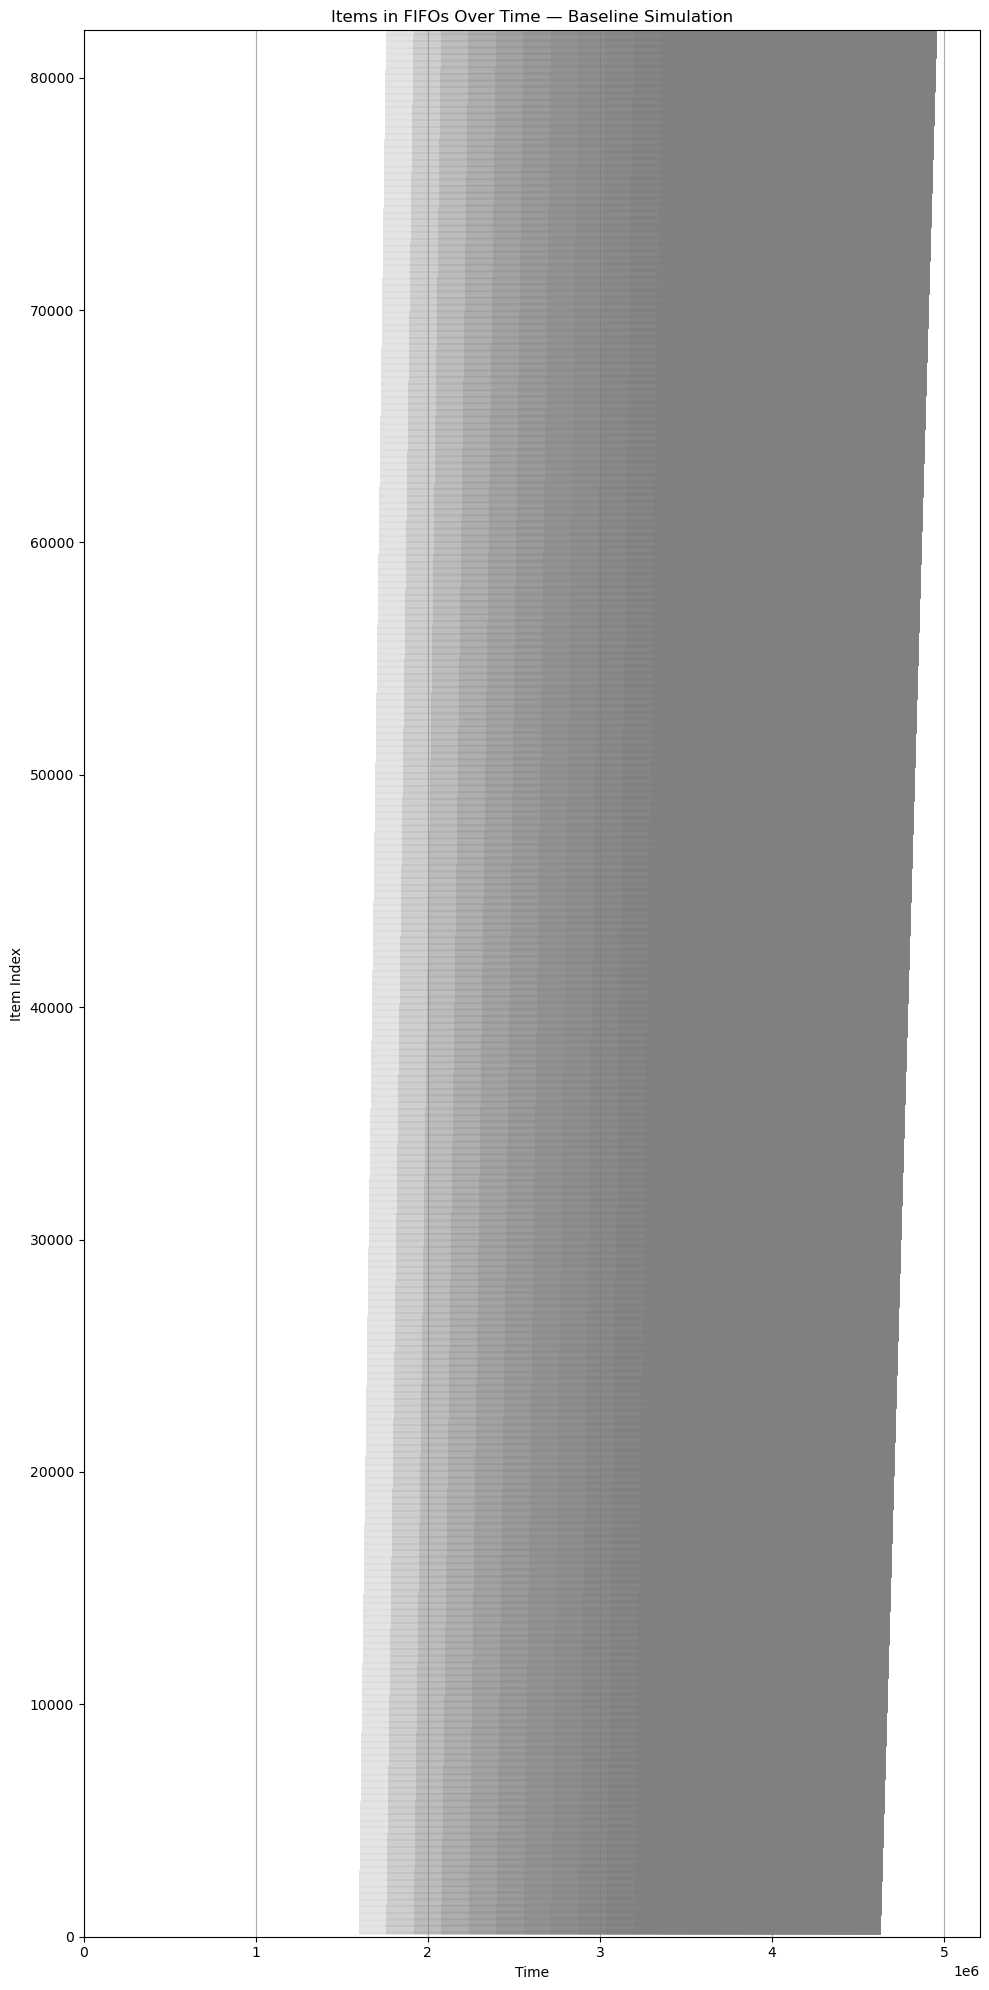

In [33]:
# make a new plot that pairs every read with every write for jus the baseline simualtion
# this would correspont to an item being in a fifo
# then for evey item in the fifo, we can draw a line left to right from write to read to show how long it was in the fifo
# the y axis is the item index
# the x axis is time
# we want to do this for all itmes in all fifos

import matplotlib
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

items = []

global_item_counter = 0
for fifo_id, data in data_fifo_accesses["base"].items():
    reads = data["reads"]
    writes = data["writes"]
    assert len(reads) == len(writes), "Reads and writes must be the same length"
    for fifo_item_index, (write, read) in enumerate(zip(writes, reads)):
        items.append((fifo_id, fifo_item_index, global_item_counter, write, read))
        global_item_counter += 1

items.sort(key=lambda x: (x[3], x[4]))  # sort by write time, then read time


writes = np.array([w for (_, _, _, w, _) in items])
reads = np.array([r for (_, _, _, _, r) in items])
ys = np.array([idx for (_, _, idx, _, _) in items])

# 1a) pick your sort key — e.g. by write time, then read time:
order = np.lexsort((writes, reads))
# or if you just want to sort by writes:
# order = np.argsort(writes)

# 1b) apply the same permutation to writes & reads
writes = writes[order]
reads = reads[order]

# 1c) now relabel y as 0,1,2,… in this new order
ys = np.arange(len(writes))


fig, ax = plt.subplots(1, 1, figsize=(10, 20))
fig: Figure = fig
axs: tuple[Axes, Axes] = axs


# line_segments = []
# for fifo_id, item_index, write, read in items:
#     # print(fifo_id, item_index, write, read)
#     line_segments.append(
#         Line2D(
#             [write, read],
#             [item_index, item_index],
#             color="black",
#             alpha=0.5,
#             linewidth=0.5,
#         )
#     )

#     # line_segments.append([[write, item_index], [read, item_index]])
#     # line_segments.append(np.array([[write, item_index], [read, item_index]]))

# # line_segments = np.array(line_segments)
# # print(line_segments.shape)

# print(line_segments)

# line_collection = LineCollection(line_segments)
# line_collection.set_snap(False)
# ax.add_collection(line_collection)
# for line_2d in line_segments:
#     ax.add_line(line_2d)

ax.hlines(
    y=ys,
    xmin=writes,
    xmax=reads,
    linewidth=0.1,
    color="gray",
    alpha=0.8,
)

ax.set_xlim(left=0, right=reads.max() * 1.05)
ax.set_ylim(bottom=ys.min() - 1, top=ys.max() + 1)

ax.set_title("Items in FIFOs Over Time — Baseline Simulation")
ax.set_xlabel("Time")
ax.set_ylabel("Item Index")
ax.grid(axis="x")

plt.tight_layout()
plt.show()
